In [1]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("mohankrishnathalla/sleep-health-and-daily-performance-dataset")
df = pd.read_csv(path + "/sleep_health_dataset.csv", index_col='person_id')
df.head()

100%|██████████| 4.07M/4.07M [00:00<00:00, 107MB/s]

Extracting files...


,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
person_id,,,,,,,,,,,,,,,,,,,,,
1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [2]:
X = pd.get_dummies(df.drop(['felt_rested', 'cognitive_performance_score',
                            'sleep_disorder_risk'], axis=1), drop_first=True)
y_bin = df['felt_rested']
y_reg = df['cognitive_performance_score']
y_class = df['sleep_disorder_risk']

# Regresión logística y clasificación simple

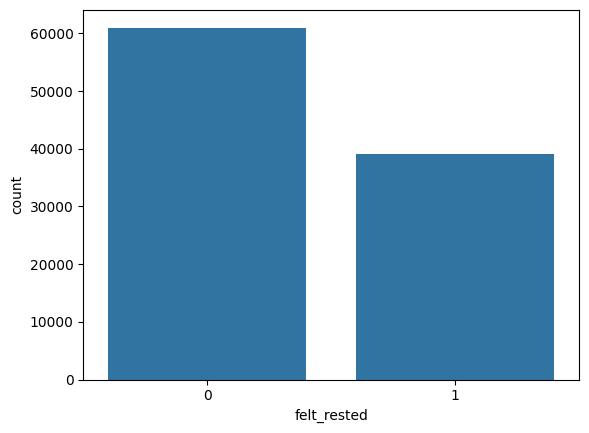

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='felt_rested', data=df)
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=42)

## Sin modificar ni nada

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

forest_model = RandomForestClassifier()
forest_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)
y_pred_forest = forest_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic regression accuracy: 0.7087
KNN accuracy: 0.5633
Decision tree accuracy: 0.6643
Random forest accuracy: 0.7396


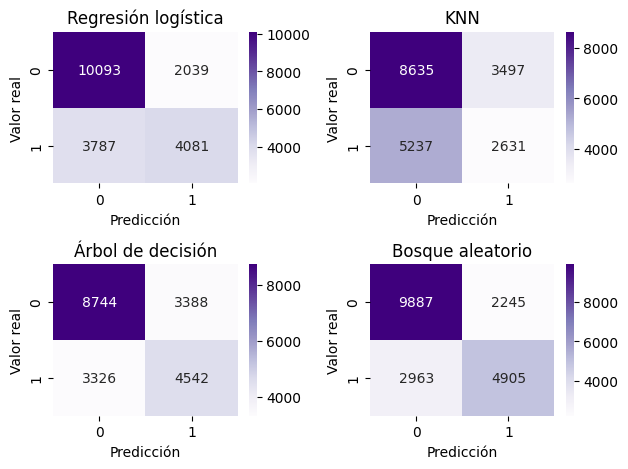

In [31]:
from sklearn.metrics import classification_report, confusion_matrix

report_log = classification_report(y_test, y_pred_log, output_dict=True)
print(f'Logistic regression accuracy: {report_log['accuracy']}')

report_knn = classification_report(y_test, y_pred_knn, output_dict=True)
print(f'KNN accuracy: {report_knn['accuracy']}')

report_tree = classification_report(y_test, y_pred_tree, output_dict=True)
print(f'Decision tree accuracy: {report_tree['accuracy']}')

report_forest = classification_report(y_test, y_pred_forest, output_dict=True)
print(f'Random forest accuracy: {report_forest['accuracy']}')

plt.subplot(2, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='.0f', cmap='Purples')
plt.title('Regresión logística')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='.0f', cmap='Purples')
plt.title('KNN')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 3)
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt='.0f', cmap='Purples')
plt.title('Árbol de decisión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 4)
sns.heatmap(confusion_matrix(y_test, y_pred_forest), annot=True, fmt='.0f', cmap='Purples')
plt.title('Bosque aleatorio')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.tight_layout()
plt.show()

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

tree_model = DecisionTreeClassifier()
tree_model.fit(X_train_scaled, y_train)

forest_model = RandomForestClassifier()
forest_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_tree = tree_model.predict(X_test_scaled)
y_pred_forest = forest_model.predict(X_test_scaled)

Logistic regression accuracy: 0.738
KNN accuracy: 0.6771
Decision tree accuracy: 0.6643
Random forest accuracy: 0.7422


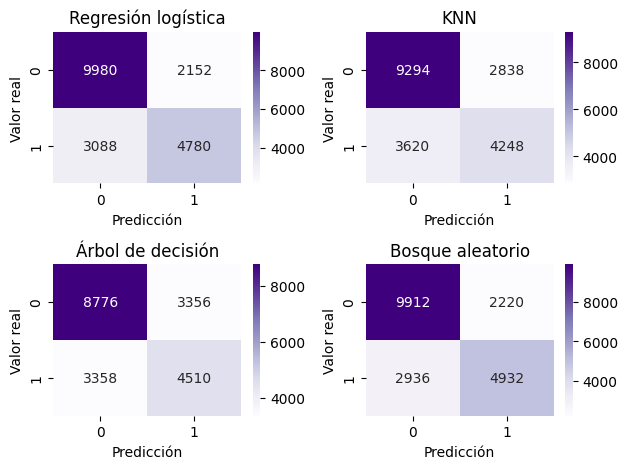

In [35]:
from sklearn.metrics import classification_report, confusion_matrix

report_log = classification_report(y_test, y_pred_log, output_dict=True)
print(f'Logistic regression accuracy: {report_log['accuracy']}')

report_knn = classification_report(y_test, y_pred_knn, output_dict=True)
print(f'KNN accuracy: {report_knn['accuracy']}')

report_tree = classification_report(y_test, y_pred_tree, output_dict=True)
print(f'Decision tree accuracy: {report_tree['accuracy']}')

report_forest = classification_report(y_test, y_pred_forest, output_dict=True)
print(f'Random forest accuracy: {report_forest['accuracy']}')

plt.subplot(2, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='.0f', cmap='Purples')
plt.title('Regresión logística')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='.0f', cmap='Purples')
plt.title('KNN')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 3)
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt='.0f', cmap='Purples')
plt.title('Árbol de decisión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 4)
sns.heatmap(confusion_matrix(y_test, y_pred_forest), annot=True, fmt='.0f', cmap='Purples')
plt.title('Bosque aleatorio')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.tight_layout()
plt.show()

# Regresión lineal

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = lin_model.predict(X_test)

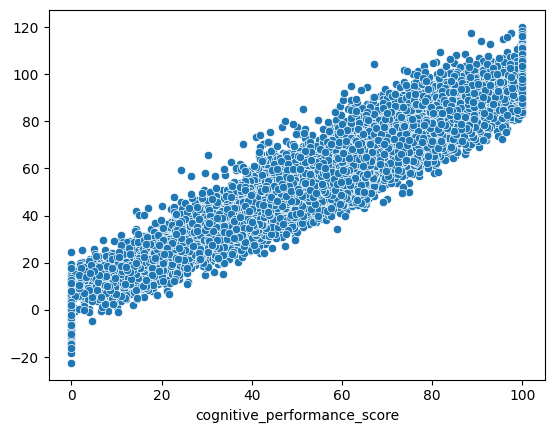

In [ ]:
sns.scatterplot(x=y_test, y=y_pred)
plt.show()

# Clasificación (4 clases)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = tree_model.predict(X_test)

              precision    recall  f1-score   support

     Healthy       0.98      0.98      0.98     10892
        Mild       0.89      0.88      0.89      6673
    Moderate       0.56      0.59      0.58      1626
      Severe       0.71      0.70      0.71       809

    accuracy                           0.90     20000
   macro avg       0.78      0.79      0.79     20000
weighted avg       0.90      0.90      0.90     20000



<Axes: >

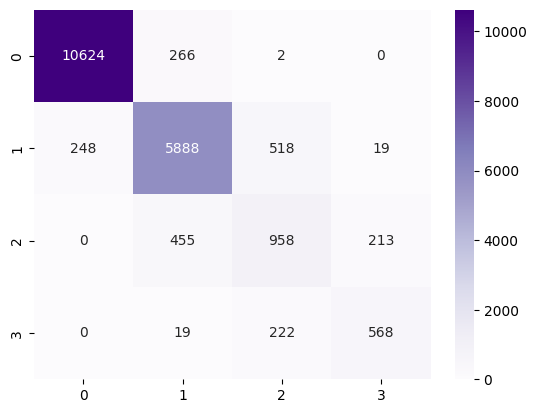

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='.0f', cmap='Purples')